In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from graphcast.model_utils import dataset_to_stacked

In [2]:
def load_and_stack_model_predictions(config, eval_dates, n_forecast_steps=None):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
    location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
    fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
    model_pred = xr.open_zarr(fname)

    # subsample
    pred = model_pred.sel(time=slice(eval_dates[0], eval_dates[1])).isel(lead_time=slice(None, n_forecast_steps))

    # stack it
    pred_stacked = dataset_to_stacked(pred, preserved_dims=("time","lead_time","lat","lon"))
    
    return pred_stacked 

In [3]:
def load_and_stack_reference_truth(config, eval_dates, n_forecast_steps=None):
    """Loads reference truth data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
    location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
    fname = f"{location}/{config['ref_truth'].lower()}.{config['duration']}.zarr"
    ref_pred = xr.open_zarr(fname)

    # subsample
    ref_pred = ref_pred.sel(time=slice(eval_dates[0], eval_dates[1])).isel(lead_time=slice(None, n_forecast_steps))

    # stack it
    ref_pred_stacked = dataset_to_stacked(ref_pred, preserved_dims=("time","lead_time","lat","lon"))
    
    return ref_pred_stacked 

In [1]:
def temporal_cross_covariance(da: xr.DataArray, dim: str = "channels", norm: bool = False):
    """
    Calculates the temporal cross-covariance or cross-correlation matrix for all pairs 
    along dim.

    Args:
        da (xr.DataArray): The input DataArray, which should be loaded into memory.
                           ('time', 'lead_time', 'lat', 'lon', 'channels').
        dim (str): The dimension along which variables are defined (e.g., "channels").
        norm (bool): If true, compute correlation instead of covariance.

    Returns:
        xr.DataArray: A DataArray containing the full covariance or correlation matrix.
    """
    
    n_ic = da.sizes["time"]
    n_leadtimes = da.sizes["lead_time"]
    n_channels = da.sizes["channels"]

    cov_mat = xr.DataArray(np.zeros((n_channels, n_channels)))

    for i in range(n_ic):
        data = da.isel(time=i)
        
        if not norm:
            statistic = "covariance"
            data_demeaned = data - data.mean(dim="lead_time", skipna=True)
            da1 = data_demeaned.rename({dim: f"{dim}_x"})
            da2 = data_demeaned.rename({dim: f"{dim}_y"})
            cov_map = xr.dot(da1, da2, dims="lead_time") / (n_leadtimes - 1)
            out_matrix = cov_map.mean(["lat", "lon"], skipna=True)

        else:
            statistic = "correlation"
            # We first z-score the data and then compute the covariance of the result.
        
            # 1. Calculate mean and sample standard deviation (with ddof=1).
            mean = data.mean(dim="lead_time", skipna=True)
            std = data.std(dim="lead_time", skipna=True, ddof=1)

            # 2. Z-score the data.
            da_zscored = (data - mean) / std

            # 3. The correlation is the covariance of the z-scored data.
            da1 = da_zscored.rename({dim: f"{dim}_x"})
            da2 = da_zscored.rename({dim: f"{dim}_y"})
            
            # The dot product of z-scored data, divided by (n-1), is the correlation map.
            corr_map = xr.dot(da1, da2, dims="lead_time") / (n_leadtimes - 1)
        
            # 4. Average the correlation map over spatial dimensions.
            out_matrix = corr_map.mean(["lat", "lon"], skipna=True)

        # add to the overall sum for all ics thus far
        cov_mat = cov_mat + out_matrix

    cov_mat = cov_mat / n_ic
    cov_mat.attrs = {"description": f"tendency {statistic}"}
    
    return out_matrix

NameError: name 'xr' is not defined

In [12]:
def plot_correlation(ax,
                     da: xr.DataArray,
                     ticks: tuple = (0, 1, 8, 15, 22, 29),
                     ticklabels: tuple = ("ssh", "so", "temp", "uo", "vo"),
                     title: str = None,
                     cmap: str = "RdBu_r",
                     vmin: float = None,
                     vmax: float = None,
                     add_colorbar: bool = False,
                    ):
    """A manuscript-ready correlation plot component."""
    # Plot the heatmap
    p = da.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=add_colorbar)

    # Draw separator lines
    for tick_pos in ticks[1:]:
        line_pos = tick_pos - 0.5
        ax.axvline(line_pos, color='gray', linestyle=':', linewidth=1.5)
        ax.axhline(line_pos, color='gray', linestyle=':', linewidth=1.5)

    # Clean up default axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Add custom axis labels
    for i in range(len(ticks) - 1):
        start, end = ticks[i], ticks[i+1]
        midpoint = (start + end - 1) / 2
        label = ticklabels[i].upper() # Use uppercase for clarity

        ax.text(-0.07, midpoint, label, ha='center', va='center', rotation='vertical',
                fontsize=11, transform=ax.get_yaxis_transform(), clip_on=False)
        ax.text(midpoint, -0.07, label, ha='center', va='center',
                fontsize=11, transform=ax.get_xaxis_transform(), clip_on=False)

    if title is not None:
        ax.set_title(title, fontsize=12, pad=10)
    
    return p

In [7]:
# ---- Config ----
EVALUATION_DATES = ("2022-01-01T00", "2022-01-01T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-Maha",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]

# Temporal Correlations

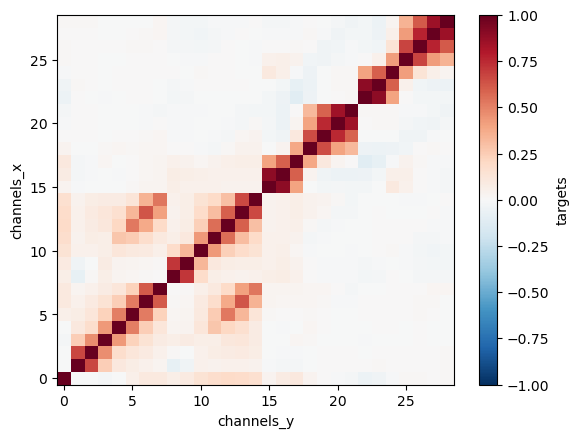

In [8]:
# ---- Reference Truth Tendency Correlations ----
# File location and name 
loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
fname = "tendency_correlation_ocn_only_24h_rm_seasonality.nc"

# open file
f = xr.open_dataset(os.path.join(loc, fname))
corr_tend_replay = f.targets
corr_tend_replay.plot()
plt.show()

In [9]:
# ---- Tendency Correlations from Model Predictions ----
all_temp_corr_mat = {}
forecast_days = 10
COMPUTE_TENDENCY = True

# Loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")

    # Load and stack model prediction data once
    print("Loading and stacking the data...")
    ds = load_and_stack_model_predictions(model_config, EVALUATION_DATES,
                                          n_forecast_steps = forecast_days)
    print("Data loading completed successfully!!!")
    
    # compute tendency
    if COMPUTE_TENDENCY:
        ds = ds.diff("lead_time")
        print("Tendency computed!!!")
    
    # compute correlation
    print("Computing correlations...")
    model_name = model_config["name"]
    all_temp_corr_mat[model_name] = temporal_cross_covariance(ds, dim="channels", norm=True).load()
    print("Correlation computed!!!")

print("\n --- All correlations computed!!! ---")


Processing Model: Emulator-24h-MSE
Loading and stacking the data...
Data loading completed successfully!!!
Tendency computed!!!
Computing correlations...
Correlation computed!!!

Processing Model: Emulator-24h-Maha
Loading and stacking the data...
Data loading completed successfully!!!
Tendency computed!!!
Computing correlations...
Correlation computed!!!

 --- All correlations computed!!! ---


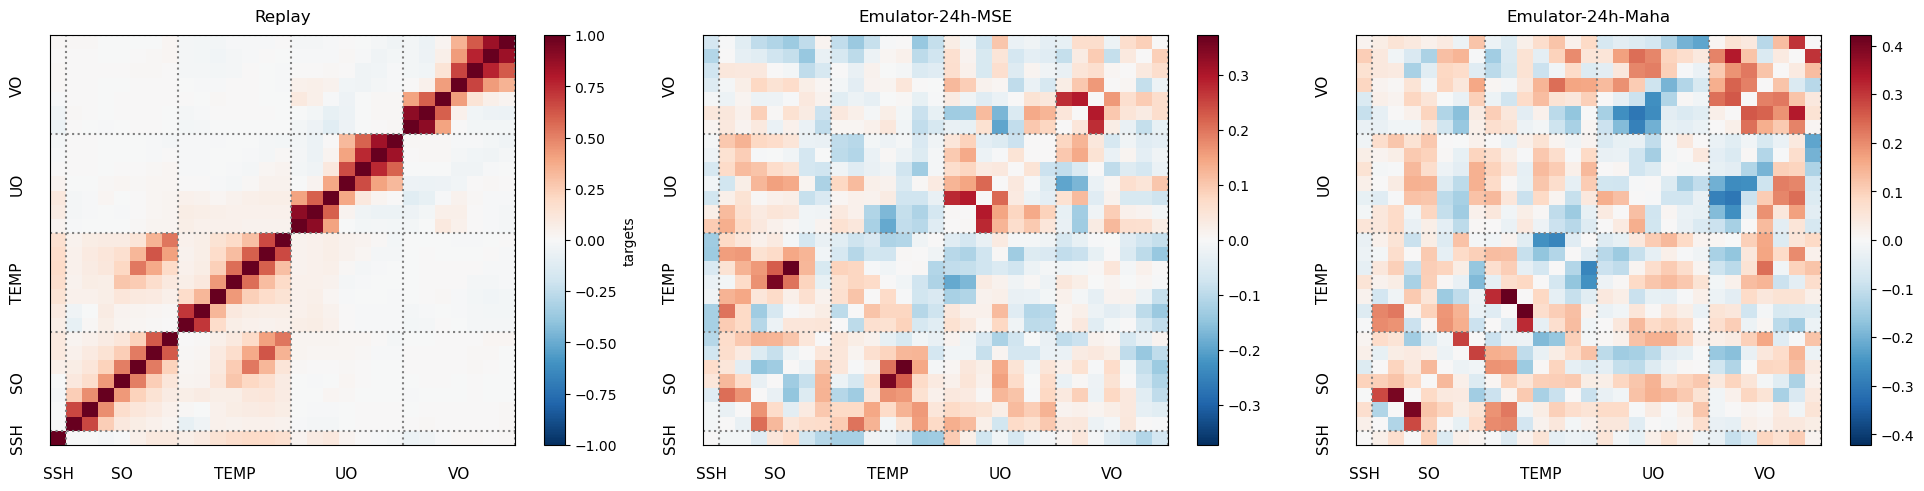

In [16]:
# ---- Plot ----
nrows = 1
ncols = len(MODELS_CONFIG)+1
fig, ax = plt.subplots(1, ncols, figsize=(6.5*ncols, 5*nrows))

# Panel 1: Reference Truth
plot_correlation(ax[0], corr_tend_replay, title=f"Replay", add_colorbar=True)

# Panel 2 onwards
for i, key in enumerate(all_temp_corr_mat.keys()):
    plot_correlation(ax[i+1],corr_tend_replay - all_temp_corr_mat[key], 
                     title=key, add_colorbar=True)

plt.tight_layout()
plt.show()